In [147]:
import torch
import torchvision
from lexplainet.implicit.rules import *

device = "cuda" if torch.cuda.is_available() else "cpu"

def model_loader(model_name, device):
    if model_name == "resnet18":
        model = torchvision.models.resnet18(pretrained=True)
    elif model_name == "resnet34":
        model = torchvision.models.resnet34(pretrained=True)
    elif model_name == "resnet50":
        model = torchvision.models.resnet50(pretrained=True)
    elif model_name == "vgg16":
        model = torchvision.models.vgg16(pretrained=True)
    elif model_name == "vgg16_bn":
        model = torchvision.models.vgg16_bn(pretrained=True)
    else:
        raise ValueError("Unsupported model name")
    
    model = model.to(device)
    model.device = device
    model.eval()
    return model

model = model_loader("vgg16_bn", device)

/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [148]:
%matplotlib inline
import matplotlib.pyplot as plt

from imagenet import IMAGENET_CLASS_NAMES
from imagenet.utils import inference_transform
from lexplainet.heatmap import show_image, load_image, plot_heatmap

Image Tensor Shape: torch.Size([1, 3, 224, 224])


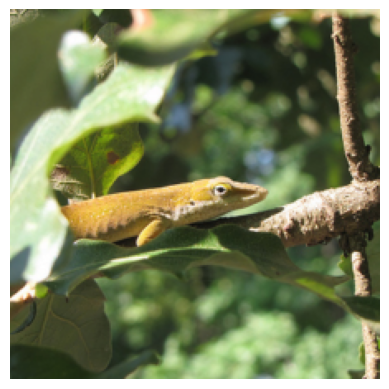

<Figure size 640x480 with 0 Axes>

In [149]:
image_tensor = load_image('./lizard.jpg', transform=inference_transform, device=device)
show_image(image_tensor, transform=inference_transform)

In [150]:
from model_utils.inference import inference, forward_pass
from model_utils.autograd import explain_model_prediction, make_gradient_output, explain_output

In [151]:
from lexplainet.implicit.model_specific_patches import canonize_resnet, canonize_vgg_bn
from lexplainet.implicit.core import patch_composite, undo_patch_all
from lexplainet.implicit.rules import gamma_rule, identity_rule, epsilon_rule

In [152]:
undo_patch_all(model)

composite = {
            torch.nn.Conv2d: (gamma_rule, {'gamma': 100.}), 
            torch.nn.ReLU: (identity_rule, {}),
            torch.nn.BatchNorm2d: (identity_rule, {}),
            torch.nn.Linear: (epsilon_rule, {})
}

# canonize_resnet(model)
canonize_vgg_bn(model)
patch_composite(model, composite)

Predicted class: 40, American chameleon, anole, Anolis carolinensis


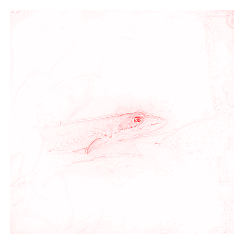

In [153]:
image_tensor.requires_grad = True

output = forward_pass(model, image_tensor, gradient_required=True)
predicted_class = output.argmax(dim=1).item()

gradient_output = make_gradient_output(output, predicted_class)
output.backward(gradient_output)

relevance = image_tensor.grad.detach().cpu() * image_tensor.detach().cpu()
lrp_normalized_relevance = (relevance / torch.max(torch.abs(relevance))).sum(dim=1)
print(f"Predicted class: {predicted_class}, {IMAGENET_CLASS_NAMES[predicted_class]}")
plot_heatmap(lrp_normalized_relevance, save=False)

In [154]:
def get_latent_relevances(layer, layer_name, storing_dict):

    def backward_hook(module, grad_input, grad_output):
        print("Backward hook called for layer:", module)
        print("Grad input shape:", [g.shape for g in grad_input])
        print("Grad output shape:", [g.shape for g in grad_output])

        # Store or process the gradients as needed
        storing_dict[f'{layer_name}'] = {'grad_input': grad_input, 'grad_output': grad_output}

    # Register the backward hook
    hook_handle = layer.register_full_backward_hook(backward_hook)
   
    return hook_handle

def modify_latent_relevances(condition_index, layer):

    def backward_hook(module, grad_output):
        # get nr of nuerons of the module
        num_neurons = grad_output[0].shape[1]  # assuming grad_output[0] has shape (batch_size, num_neurons, ...)
        print("Backward hook called for layer:", module)
        print("Grad output shape:", [g.shape for g in grad_output])

        if condition_index < num_neurons:
            mask = torch.zeros_like(grad_output[0])
            mask[:, condition_index, ...] = 1  # Keep only the relevance for the specified neuron

            print("Mask shape:", mask.shape)
            print("Condition index:", condition_index)

            # want to modify the gradient_output to only keep the relevance for the specified neuron
            modified_gradient_output = tuple(mask * g for g in grad_output)
            print("Modified grad output shape:", [g.shape for g in modified_gradient_output])
            return modified_gradient_output
        
    # register pre hook
    hook_handle = layer.register_full_backward_pre_hook(backward_hook)

    return hook_handle

In [155]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

Backward hook called for layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Grad output shape: [torch.Size([1, 512, 14, 14])]
Mask shape: torch.Size([1, 512, 14, 14])
Condition index: 35
Modified grad output shape: [torch.Size([1, 512, 14, 14])]


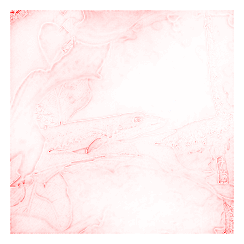

In [156]:
layer = model.features[40]
neuron_index = 35
hook_handle_mask = modify_latent_relevances(neuron_index, layer)

image_tensor.requires_grad = True

output = forward_pass(model, image_tensor, gradient_required=True)
predicted_class = output.argmax(dim=1).item()

gradient_output = make_gradient_output(output, predicted_class)
output.backward(gradient_output)

relevance = image_tensor.grad.detach().cpu() * image_tensor.detach().cpu()
lrp_normalized_relevance = (relevance / torch.max(torch.abs(relevance))).sum(dim=1)
plot_heatmap(lrp_normalized_relevance)
hook_handle_mask.remove()

In [157]:
def get_layer_name(model, module):
    for name, mod in model.named_modules():
        if mod is module:
            return name
    return None

def compute_relevance(model, input_tensor, predicted_class=None, init_relevance="logit"):
    input_tensor.requires_grad = True

    output = forward_pass(model, image_tensor, gradient_required=True)
    if predicted_class is None:
        predicted_class = output.argmax(dim=1).item()

    gradient_output = None
    if init_relevance == "logit":
        gradient_output = make_gradient_output(output, predicted_class)
        init_relevance = output[0, predicted_class].item()
    elif init_relevance is not None:
        if init_relevance == 1:
            gradient_output = make_gradient_output(torch.ones_like(output), predicted_class)
        elif init_relevance == -1:
            gradient_output = make_gradient_output(-torch.ones_like(output), predicted_class)
    
    output.backward(gradient_output)

    relevance = image_tensor.grad.detach().cpu() * image_tensor.detach().cpu()
    lrp_normalized_relevance = (relevance / torch.max(torch.abs(relevance))).sum(dim=1)
    return lrp_normalized_relevance, predicted_class, init_relevance

def show_multiplt_heatmaps(heatmaps):
    num_heatmaps = len(heatmaps)
    fig, axes = plt.subplots(1, num_heatmaps, figsize=(5 * num_heatmaps, 5))
    for i, heatmap_dict in enumerate(heatmaps):
        axes[i].imshow(heatmap_dict["heatmap"], cmap="seismic", clim=(-heatmap_dict["clim"], heatmap_dict["clim"]))
        axes[i].axis("off")
        # also show conditioning info on each axes in multiple lines
        # axes[i].set_title(f"Init Rel: {heatmap_dict['init_relevance']:.2f}, Layer: {get_layer_name(model, conditioning_dictionary[i]['layer'])}\nNeuron: {conditioning_dictionary[i]['neuron_index']}, Predicted class: {conditioning_dictionary[i].get('predicted_class', 'N/A')}")
        axes[i].set_title(f"Init Rel: {heatmap_dict['init_relevance']:.2f}, Layer: {heatmap_dict['layer_name']}\nPredicted class: {heatmap_dict['predicted_class']}, Neuron index: {heatmap_dict['neuron_index']}")

    plt.tight_layout()
    plt.show()

def compute_crp_heatmaps(model, image_tensor, conditioning_dictionary, init_relevance="logit", show=False):
    # heatmaps to stack
    heatmaps = []
    init_relevances = []
    for conditioning in conditioning_dictionary:
        layer = conditioning["layer"]
        neuron_index = conditioning["neuron_index"]
        predicted_class = conditioning.get("predicted_class", None)
        hook_handle_mask = modify_latent_relevances(neuron_index, layer)

        print(f"Computing relevance for layer: {get_layer_name(model, layer)}, neuron index: {neuron_index}, predicted class: {predicted_class}, init relevance: {init_relevance}")
        lrp_normalized_relevance, predicted_class, computed_init_relevance = compute_relevance(model,
                                                                                    image_tensor,
                                                                                    predicted_class=predicted_class,
                                                                                    init_relevance=init_relevance)
        init_relevances.append(computed_init_relevance)

        heatmap, clim = plot_heatmap(lrp_normalized_relevance, show=False)
        heatmaps.append({"heatmap": heatmap, "clim": clim, "init_relevance": computed_init_relevance, "predicted_class": predicted_class, "layer_name": get_layer_name(model, layer), "neuron_index": neuron_index})
        hook_handle_mask.remove()

    if not show:
        return heatmaps
    else:
    # now show multiple heatmaps together, each in a subplot
        show_multiplt_heatmaps(heatmaps)



Computing relevance for layer: features.40, neuron index: 35, predicted class: 46, init relevance: logit
Backward hook called for layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Grad output shape: [torch.Size([1, 512, 14, 14])]
Mask shape: torch.Size([1, 512, 14, 14])
Condition index: 35
Modified grad output shape: [torch.Size([1, 512, 14, 14])]
Computing relevance for layer: features.20, neuron index: 10, predicted class: 2, init relevance: logit
Backward hook called for layer: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Grad output shape: [torch.Size([1, 256, 56, 56])]
Mask shape: torch.Size([1, 256, 56, 56])
Condition index: 10
Modified grad output shape: [torch.Size([1, 256, 56, 56])]


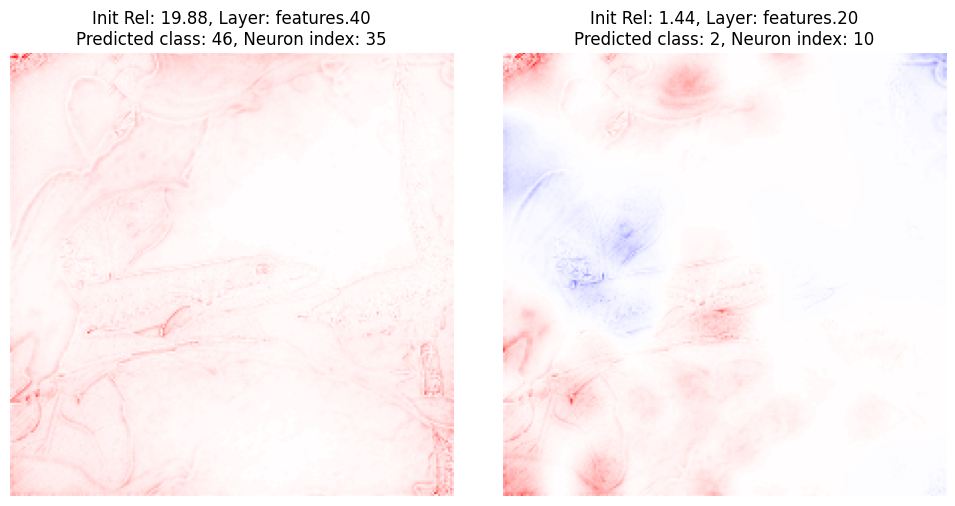

In [159]:
conditioning_dict = [{"layer":  model.features[40], "neuron_index": 35, "predicted_class": 46}, {"layer":  model.features[20], "neuron_index": 10, "predicted_class": 2}]
heatmaps = compute_crp_heatmaps(model, image_tensor, conditioning_dict, init_relevance="logit", show=True)

Computing relevance for layer: features.40, neuron index: 35, predicted class: 46, init relevance: 1
Backward hook called for layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Grad output shape: [torch.Size([1, 512, 14, 14])]
Mask shape: torch.Size([1, 512, 14, 14])
Condition index: 35
Modified grad output shape: [torch.Size([1, 512, 14, 14])]
Computing relevance for layer: features.20, neuron index: 10, predicted class: 2, init relevance: 1
Backward hook called for layer: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Grad output shape: [torch.Size([1, 256, 56, 56])]
Mask shape: torch.Size([1, 256, 56, 56])
Condition index: 10
Modified grad output shape: [torch.Size([1, 256, 56, 56])]


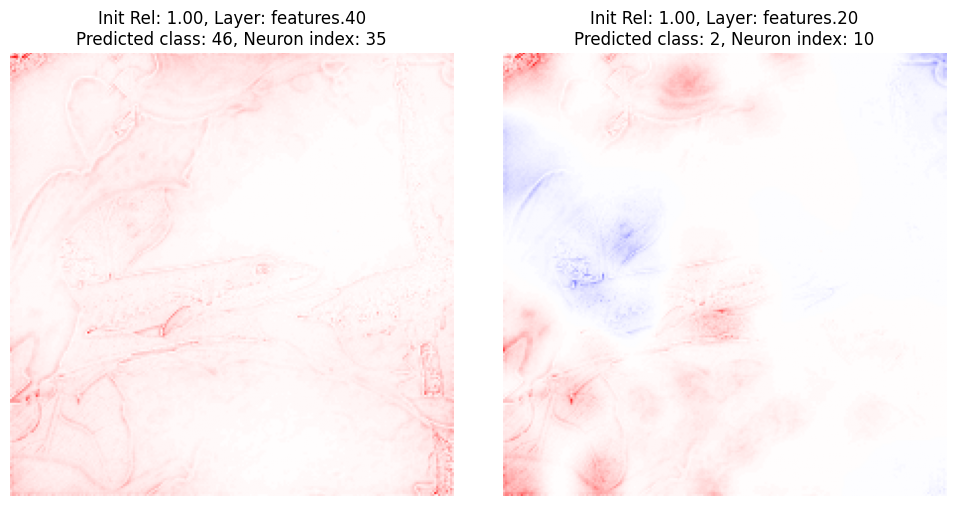

In [160]:
conditioning_dict = [{"layer":  model.features[40], "neuron_index": 35, "predicted_class": 46}, {"layer":  model.features[20], "neuron_index": 10, "predicted_class": 2}]
heatmaps = compute_crp_heatmaps(model, image_tensor, conditioning_dict, init_relevance=1, show=True)

Computing relevance for layer: features.40, neuron index: 35, predicted class: 46, init relevance: -1
Backward hook called for layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Grad output shape: [torch.Size([1, 512, 14, 14])]
Mask shape: torch.Size([1, 512, 14, 14])
Condition index: 35
Modified grad output shape: [torch.Size([1, 512, 14, 14])]
Computing relevance for layer: features.20, neuron index: 10, predicted class: 2, init relevance: -1
Backward hook called for layer: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Grad output shape: [torch.Size([1, 256, 56, 56])]
Mask shape: torch.Size([1, 256, 56, 56])
Condition index: 10
Modified grad output shape: [torch.Size([1, 256, 56, 56])]


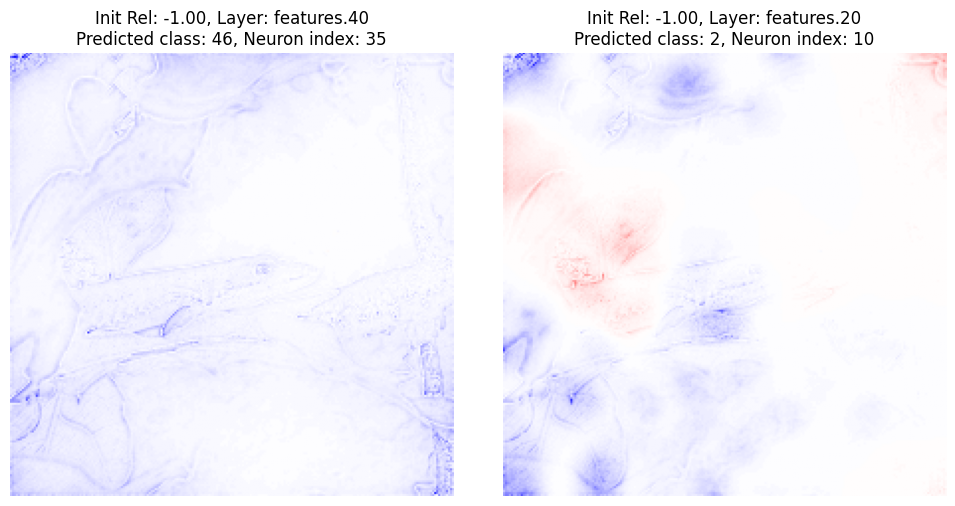

In [161]:
conditioning_dict = [{"layer":  model.features[40], "neuron_index": 35, "predicted_class": 46}, {"layer":  model.features[20], "neuron_index": 10, "predicted_class": 2}]
heatmaps = compute_crp_heatmaps(model, image_tensor, conditioning_dict, init_relevance=-1, show=True)

In [163]:
num_neurons = layer.out_channels if type(layer) == torch.nn.Conv2d else layer.out_features
num_neurons

512

In [164]:
# conditioning_dict = [{"layer":  model.features[40], "neuron_index": 35, "predicted_class": 46}, {"layer":  model.features[20], "neuron_index": 10, "predicted_class": 2}]
layer_to_investige = model.features[40]
predicted_class = 46
conditioning_dict = [{"layer": layer_to_investige, "neuron_index": neuron_index, "predicted_class": predicted_class} for neuron_index in range(num_neurons)]

In [166]:
def compute_crp_heatmaps(model, image_tensor, conditioning_dictionary, init_relevance="logit", show=False):
    # heatmaps to stack
    heatmaps = []
    init_relevances = []
    # attach a hook to get latent_relevances
    
    storing_dict = {}
    storing_hook_handle = get_latent_relevances(conditioning_dictionary[0]["layer"], get_layer_name(model, conditioning_dictionary[0]["layer"]), storing_dict)

    for conditioning in conditioning_dictionary:
        layer = conditioning["layer"]
        neuron_index = conditioning["neuron_index"]
        predicted_class = conditioning.get("predicted_class", None)
        hook_handle_mask = modify_latent_relevances(neuron_index, layer)

        print(f"Computing relevance for layer: {get_layer_name(model, layer)}, neuron index: {neuron_index}, predicted class: {predicted_class}, init relevance: {init_relevance}")
        lrp_normalized_relevance, predicted_class, computed_init_relevance = compute_relevance(model,
                                                                                    image_tensor,
                                                                                    predicted_class=predicted_class,
                                                                                    init_relevance=init_relevance)
        init_relevances.append(computed_init_relevance)

        heatmap, clim = plot_heatmap(lrp_normalized_relevance, show=False)
        # also fetch the grad_output for the layer from the storing_dict and print its shape
        latent_relevance = storing_dict.get(get_layer_name(model, layer), {}).get("grad_output", None)[0].squeeze(0)
        heatmaps.append({"heatmap": heatmap, "latent_relevance": latent_relevance, "clim": clim, "init_relevance": computed_init_relevance, "predicted_class": predicted_class, "layer_name": get_layer_name(model, layer), "neuron_index": neuron_index})
        hook_handle_mask.remove()
    storing_hook_handle.remove()
    return heatmaps

In [167]:
heatmaps = compute_crp_heatmaps(model, image_tensor, conditioning_dict, init_relevance="logit", show=False)

Computing relevance for layer: features.40, neuron index: 0, predicted class: 46, init relevance: logit
Backward hook called for layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Grad output shape: [torch.Size([1, 512, 14, 14])]
Mask shape: torch.Size([1, 512, 14, 14])
Condition index: 0
Modified grad output shape: [torch.Size([1, 512, 14, 14])]
Backward hook called for layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Grad input shape: [torch.Size([1, 512, 14, 14])]
Grad output shape: [torch.Size([1, 512, 14, 14])]
Computing relevance for layer: features.40, neuron index: 1, predicted class: 46, init relevance: logit
Backward hook called for layer: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Grad output shape: [torch.Size([1, 512, 14, 14])]
Mask shape: torch.Size([1, 512, 14, 14])
Condition index: 1
Modified grad output shape: [torch.Size([1, 512, 14, 14])]
Backward hook called for layer: Conv2d(512, 512, kernel

In [205]:
stats = torch.tensor([heatmaps[neuron_index]['latent_relevance'].sum() for neuron_index in range(num_neurons)])
# get top 5 indices and values
topk_values, topk_indices = torch.topk(stats, k=5)
print("Top 5 neuron indices with highest latent relevance:", topk_indices)
print("Top 5 highest latent relevance values:", topk_values)

Top 5 neuron indices with highest latent relevance: tensor([ 39, 170,  77, 373, 182])
Top 5 highest latent relevance values: tensor([35774.0977,   500.0872,   349.9147,   339.6207,   272.4974])


Latent relevance sums for top 5 neurons: tensor([35774.0977,   500.0872,   349.9147,   339.6207,   272.4974])


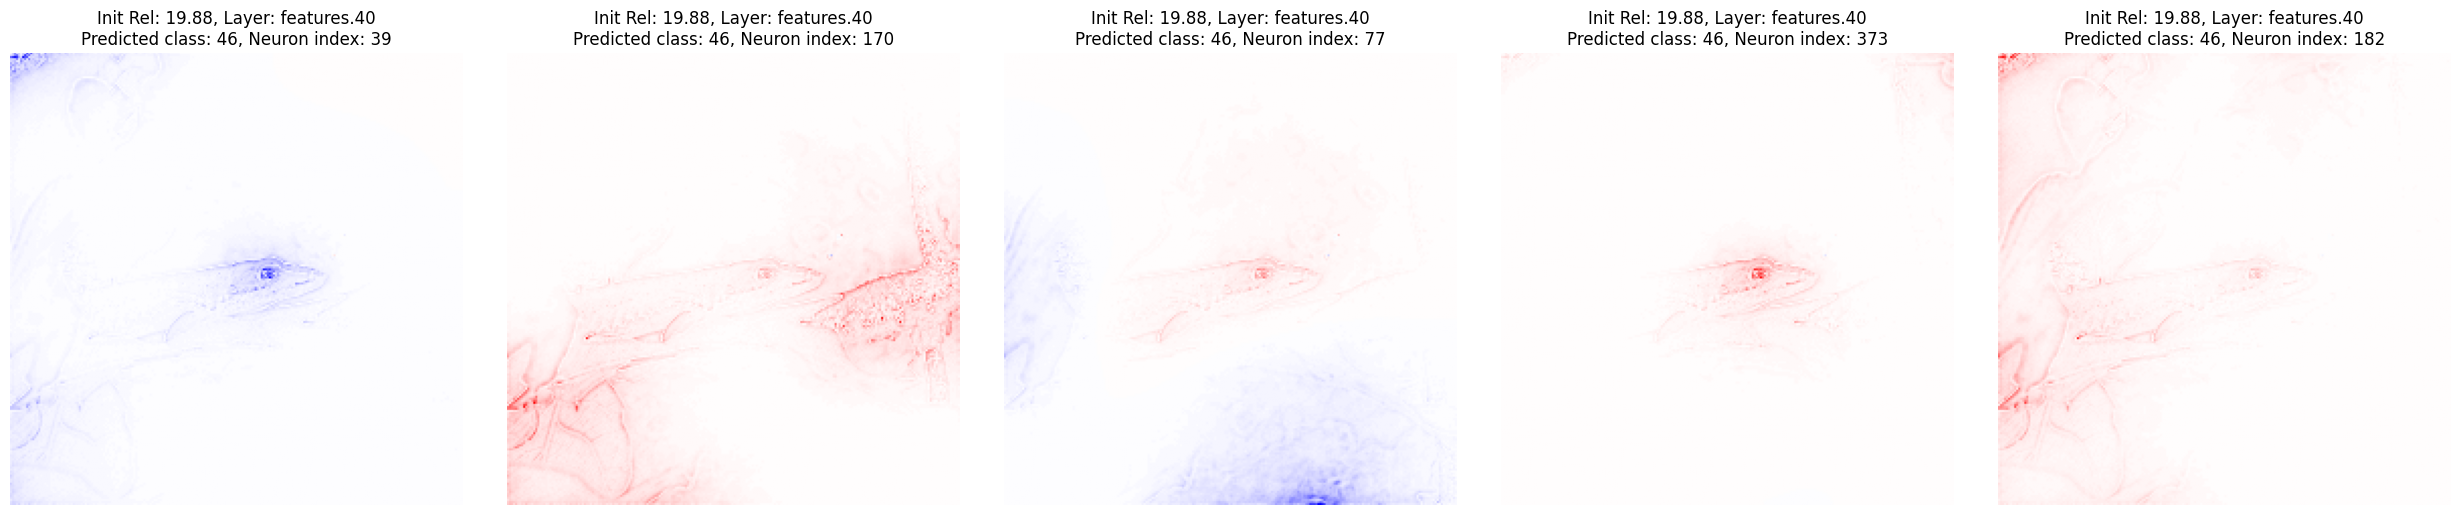

In [207]:
# fetch those indices from the heatmaps
heatmaps_to_plot = [heatmaps[neuron_index] for neuron_index in topk_indices]
print(f'Latent relevance sums for top 5 neurons: {topk_values}')
show_multiplt_heatmaps(heatmaps_to_plot)